# 第307章: 意味ベクトルと属性編集（InterFaceGAN）

## 📋 この章で学ぶこと

この章を終えると、以下ができるようになります：

- [ ] InterFaceGANの核心アイデア（SVM境界面＝属性方向）を説明できる
- [ ] 潜在空間内の属性境界面をSVMで学習し、属性方向ベクトルを計算できる
- [ ] 属性強度を連続的に制御して画像を編集できる
- [ ] 直交射影を使って、ある属性を変えても他の属性への干渉を抑制できる

## 🎯 前提知識

- ✅ Notebook 302（潜在ベクトル演算、属性ベクトル）
- ✅ Notebook 305-306（GAN潜在空間、Slerp）
- ✅ SVMの基本概念（超平面分離）

⏱️ **推定学習時間**: 90-120分
📊 **難易度**: ★★★★☆（上級）
🎓 **カテゴリ**: 理論・実践

---

## 🌟 はじめに

302章では、属性ベクトルを「グループ平均の差」として手動で発見しました。
**InterFaceGAN**は、これをより理論的・体系的に行う手法です。

### 🤔 InterFaceGANの核心アイデア

> **潜在空間内の属性の変化は、超平面（ハイパープレーン）で分離できる。
> その超平面の法線ベクトルが「属性方向」である。**

```
  潜在空間（2D簡略図）

  笑顔でない │  笑顔
             │
    ●  ●     │  ○  ○
       ●     │    ○
    ●        │  ○   ○
             │         ← SVM境界面
    ● = 無表情サンプル
    ○ = 笑顔サンプル
    →  法線ベクトル n = 「笑顔方向」
```

### 302章（手動）との違い

| 手法 | 302章: グループ平均差 | InterFaceGAN: SVM境界面 |
|------|---------------------|------------------------|
| 精度 | 中程度 | 高い（最適分離） |
| 理論 | ヒューリスティック | 最大マージン分離 |
| 干渉抑制 | なし | 直交射影で可能 |
| 必要なもの | ラベル付きデータ | ラベル付きデータ |

### 📝 この章の構成

1. **SVM境界面の学習** — 属性ラベルから超平面を発見
2. **属性方向ベクトルの抽出** — 法線ベクトル＝編集方向
3. **属性強度の制御** — αを変えて連続的に画像を変える
4. **属性干渉の問題** — 1つの属性を変えると他も変わる
5. **直交射影による干渉抑制** — Gram-Schmidtで属性を直交化

In [1]:
# ============================================================
# 環境設定
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')

def setup_japanese_font():
    japanese_fonts = ['Hiragino Sans', 'Yu Gothic', 'MS Gothic', 'Noto Sans CJK JP', 'IPAexGothic']
    available_fonts = set(f.name for f in fm.fontManager.ttflist)
    for font in japanese_fonts:
        if font in available_fonts:
            plt.rcParams['font.family'] = font
            plt.rcParams['axes.unicode_minus'] = False
            return font
    return None

font_used = setup_japanese_font()
device = torch.device('cuda' if torch.cuda.is_available()
                      else 'mps' if torch.backends.mps.is_available()
                      else 'cpu')
torch.manual_seed(42)
np.random.seed(42)
plt.rcParams['figure.figsize'] = (12, 8)

print(f"Device: {device}")
print("✅ 環境設定完了")

Disabling PyTorch because PyTorch >= 2.4 is required but found 2.1.2
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
C:\Users\yuzup\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Device: cpu
✅ 環境設定完了


In [2]:
# ============================================================
# VAEの学習（属性編集のベースモデル）
# エンコーダがあるVAEのほうが実験しやすいため使用
# ============================================================

class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = nn.Sequential(
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
        )
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 784), nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = mu + torch.exp(0.5 * logvar) * torch.randn_like(logvar)
        return self.decode(z), mu, logvar

transform = transforms.ToTensor()
train_ds = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_ds = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

model = VAE(latent_dim=20).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print("VAE (z=20) 学習中...")
for epoch in range(2):
    model.train()
    total = 0
    for x, _ in train_loader:
        x = x.view(-1, 784).to(device)
        recon, mu, logvar = model(x)
        loss = nn.functional.binary_cross_entropy(recon, x, reduction='sum') \
               - 0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total += loss.item()
    if (epoch+1) % 5 == 0:
        print(f"  Epoch {epoch+1}/20 | Loss: {total/len(train_ds):.2f}")

# 潜在ベクトル抽出
model.eval()
all_z, all_labels, all_images = [], [], []
with torch.no_grad():
    for x, y in test_loader:
        mu, _ = model.encode(x.view(-1, 784).to(device))
        all_z.append(mu.cpu().numpy())
        all_labels.append(y.numpy())
        all_images.append(x.numpy())

all_z = np.concatenate(all_z)
all_labels = np.concatenate(all_labels)
all_images = np.concatenate(all_images)

print("✅ VAE学習・潜在ベクトル抽出完了")

VAE (z=20) 学習中...
✅ VAE学習・潜在ベクトル抽出完了


---

## 1. SVM境界面の学習 — 属性方向の発見

InterFaceGANの手順:
1. 潜在ベクトル z と属性ラベル y を用意
2. 線形SVM で z → y を分類
3. SVMの **法線ベクトル** = 属性方向

MNISTでは「数字ラベル」と「画像の物理的属性」を使います。

In [3]:
# ============================================================
# 属性ラベルの計算
# MNISTで使える属性: 太さ、傾き、丸み、上下位置
# ============================================================

def compute_attributes(images):
    """画像から物理的属性を計算"""
    n = len(images)
    attrs = {}

    imgs = images.reshape(n, 28, 28)

    # 1. 太さ（ピクセル密度）
    ink = imgs.sum(axis=(1, 2))
    attrs['thickness'] = (ink > np.median(ink)).astype(int)

    # 2. 傾き（上部と下部の重心x座標の差）
    slants = []
    for img in imgs:
        ys, xs = np.where(img > 0.3)
        if len(xs) < 10:
            slants.append(0)
            continue
        upper = ys < 14
        lower = ys >= 14
        if upper.sum() < 3 or lower.sum() < 3:
            slants.append(0)
        else:
            ux = np.average(xs[upper], weights=img[ys[upper], xs[upper]])
            lx = np.average(xs[lower], weights=img[ys[lower], xs[lower]])
            slants.append(ux - lx)
    slants = np.array(slants)
    attrs['slant'] = (slants > np.median(slants)).astype(int)

    # 3. 高さ（重心y座標）
    heights = []
    for img in imgs:
        ys, xs = np.where(img > 0.3)
        if len(ys) == 0:
            heights.append(14)
        else:
            heights.append(np.average(ys, weights=img[ys, xs]))
    heights = np.array(heights)
    attrs['height'] = (heights > np.median(heights)).astype(int)

    # 4. 幅（有効ピクセルのx方向の範囲）
    widths = []
    for img in imgs:
        ys, xs = np.where(img > 0.3)
        if len(xs) == 0:
            widths.append(14)
        else:
            widths.append(xs.max() - xs.min())
    widths = np.array(widths)
    attrs['width'] = (widths > np.median(widths)).astype(int)

    return attrs

attributes = compute_attributes(all_images)
print("✅ 属性計算完了")
for name, vals in attributes.items():
    print(f"  {name}: {vals.sum()}/{len(vals)} が正クラス")

✅ 属性計算完了
  thickness: 5000/10000 が正クラス
  slant: 5000/10000 が正クラス
  height: 5000/10000 が正クラス
  width: 4946/10000 が正クラス


In [4]:
# ============================================================
# InterFaceGAN: SVMで属性境界面を学習
# ============================================================

def find_attribute_direction(z_data, labels, attr_name=""):
    """SVMで属性方向を見つける（InterFaceGAN方式）"""
    scaler = StandardScaler()
    z_scaled = scaler.fit_transform(z_data)

    svm = LinearSVC(C=1.0, max_iter=5000, random_state=42)
    svm.fit(z_scaled, labels)

    # 法線ベクトル（元のスケールに戻す）
    direction = svm.coef_[0] / scaler.scale_
    direction = direction / np.linalg.norm(direction)  # 正規化

    accuracy = svm.score(z_scaled, labels)
    print(f"  {attr_name}: SVM精度 = {accuracy:.3f}")

    return direction

print("属性方向の学習:")
directions = {}
for attr_name, attr_labels in attributes.items():
    directions[attr_name] = find_attribute_direction(all_z, attr_labels, attr_name)

print("\n✅ 全属性方向の学習完了")

属性方向の学習:
  thickness: SVM精度 = 0.902
  slant: SVM精度 = 0.933
  height: SVM精度 = 0.557
  width: SVM精度 = 0.915

✅ 全属性方向の学習完了


---

## 2. 属性方向ベクトルによる画像編集

SVMで見つけた法線ベクトル n を使って画像を編集します：

$$z' = z + \alpha \cdot n$$

- α > 0: 属性を強める
- α < 0: 属性を弱める
- |α| が大きいほど変化が強い

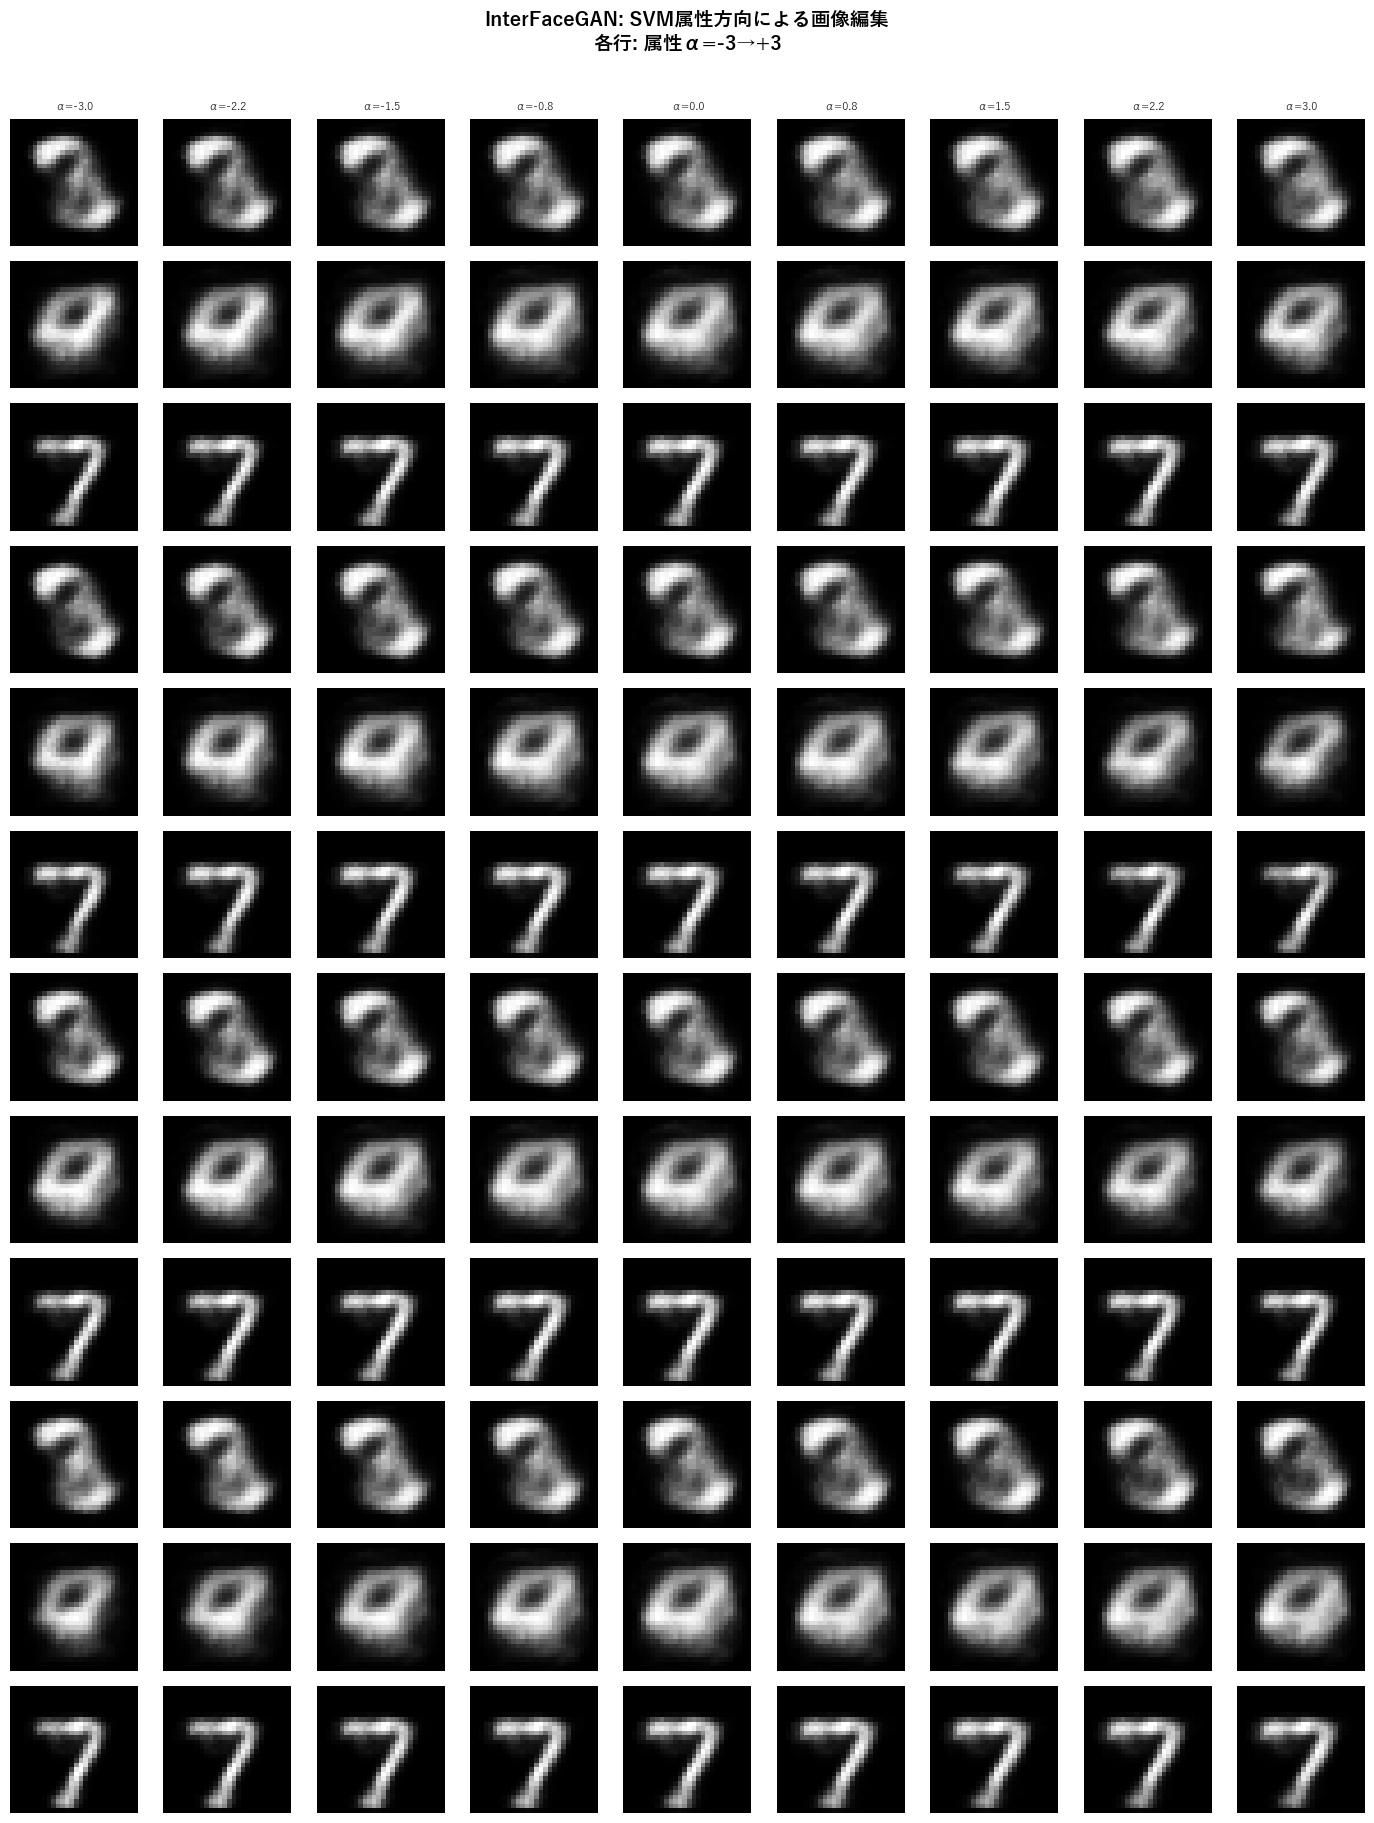

💡 各属性が独立に変化しているか確認してください
   太さを変えたのに傾きも変わる → 属性間の干渉


In [5]:
# ============================================================
# 属性編集の可視化
# ============================================================

def decode_z(z_vec):
    with torch.no_grad():
        z_t = torch.tensor(z_vec, dtype=torch.float32).unsqueeze(0).to(device)
        return model.decode(z_t).cpu().numpy().reshape(28, 28)

digit_indices = {d: np.where(all_labels == d)[0] for d in range(10)}

# 4つの属性 × 3つの数字で編集
attr_names = ['thickness', 'slant', 'height', 'width']
attr_labels_jp = {'thickness': '太さ', 'slant': '傾き', 'height': '上下位置', 'width': '幅'}
digits_show = [3, 5, 7]
n_steps = 9
alphas = np.linspace(-3, 3, n_steps)

fig, axes = plt.subplots(len(attr_names) * len(digits_show), n_steps,
                         figsize=(14, len(attr_names) * len(digits_show) * 1.5))

row = 0
for attr_name in attr_names:
    direction = directions[attr_name]
    for digit in digits_show:
        idx = digit_indices[digit][0]
        z_base = all_z[idx]

        for col, alpha in enumerate(alphas):
            z_mod = z_base + alpha * direction
            img = decode_z(z_mod)
            axes[row, col].imshow(img, cmap='gray')
            axes[row, col].axis('off')
            if col == 0:
                axes[row, col].set_ylabel(f'{digit} {attr_labels_jp[attr_name]}',
                                         fontsize=9, rotation=0, labelpad=55)
            if row == 0:
                axes[row, col].set_title(f'α={alpha:.1f}', fontsize=8)
        row += 1

fig.suptitle('InterFaceGAN: SVM属性方向による画像編集\n各行: 属性α=-3→+3',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_307_01_attribute_editing.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 各属性が独立に変化しているか確認してください")
print("   太さを変えたのに傾きも変わる → 属性間の干渉")

---

## 3. 属性干渉の問題

太さを変えると傾きも変わってしまう — これが**属性干渉**（attribute entanglement）です。

### なぜ干渉が起きるか？

属性方向ベクトルが互いに直交していないためです：

```
  潜在空間内での属性方向

        ↑ 太さ方向 n₁
       ╱
      ╱  ← 角度θ < 90° だと干渉する
     ╱
    →  傾き方向 n₂
```

### 解決策: 直交射影（Gram-Schmidt法）

n₂ から n₁ 成分を取り除くことで、n₁に干渉しない「純粋なn₂」を作れます：

$$n_2' = n_2 - (n_2 \cdot n_1) \cdot n_1$$

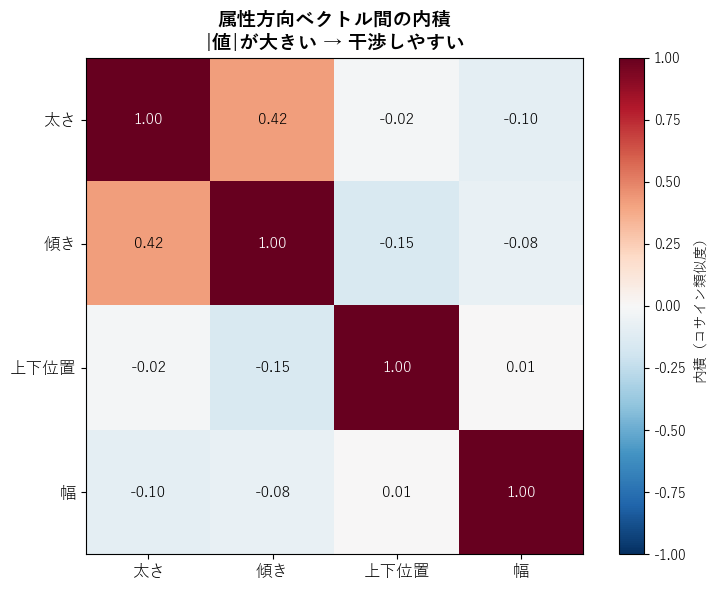

💡 対角以外で |内積| > 0.3 のペアは干渉リスクが高い


In [6]:
# ============================================================
# 属性方向間の相関（内積）分析
# ============================================================

n_attrs = len(attr_names)
dot_matrix = np.zeros((n_attrs, n_attrs))

for i, a1 in enumerate(attr_names):
    for j, a2 in enumerate(attr_names):
        dot_matrix[i, j] = np.dot(directions[a1], directions[a2])

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

im = ax.imshow(dot_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
labels_jp = [attr_labels_jp[a] for a in attr_names]
ax.set_xticks(range(n_attrs))
ax.set_yticks(range(n_attrs))
ax.set_xticklabels(labels_jp, fontsize=12)
ax.set_yticklabels(labels_jp, fontsize=12)

for i in range(n_attrs):
    for j in range(n_attrs):
        color = 'white' if abs(dot_matrix[i, j]) > 0.5 else 'black'
        ax.text(j, i, f'{dot_matrix[i, j]:.2f}', ha='center', va='center',
               fontsize=11, color=color)

plt.colorbar(im, label='内積（コサイン類似度）')
ax.set_title('属性方向ベクトル間の内積\n|値|が大きい → 干渉しやすい', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_307_02_direction_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 対角以外で |内積| > 0.3 のペアは干渉リスクが高い")

In [7]:
# ============================================================
# 直交射影による干渉抑制（Gram-Schmidt法）
# ============================================================

def orthogonalize(target_dir, ref_dirs):
    """target_dirからref_dirsの成分を直交射影で除去"""
    result = target_dir.copy()
    for ref in ref_dirs:
        ref_norm = ref / (np.linalg.norm(ref) + 1e-10)
        result = result - np.dot(result, ref_norm) * ref_norm
    return result / (np.linalg.norm(result) + 1e-10)

# 太さ方向を基準として、他の属性を直交化
base_attr = 'thickness'
orthogonal_directions = {base_attr: directions[base_attr]}

for attr in attr_names:
    if attr != base_attr:
        orthogonal_directions[attr] = orthogonalize(
            directions[attr], [directions[base_attr]])

# 直交化後の内積を確認
print("直交化後の内積:")
for attr in attr_names:
    if attr != base_attr:
        dot = np.dot(orthogonal_directions[attr], orthogonal_directions[base_attr])
        print(f"  {attr_labels_jp[base_attr]} ∙ {attr_labels_jp[attr]} = {dot:.6f} (≈0であれば直交)")

直交化後の内積:
  太さ ∙ 傾き = 0.000000 (≈0であれば直交)
  太さ ∙ 上下位置 = -0.000000 (≈0であれば直交)
  太さ ∙ 幅 = -0.000000 (≈0であれば直交)


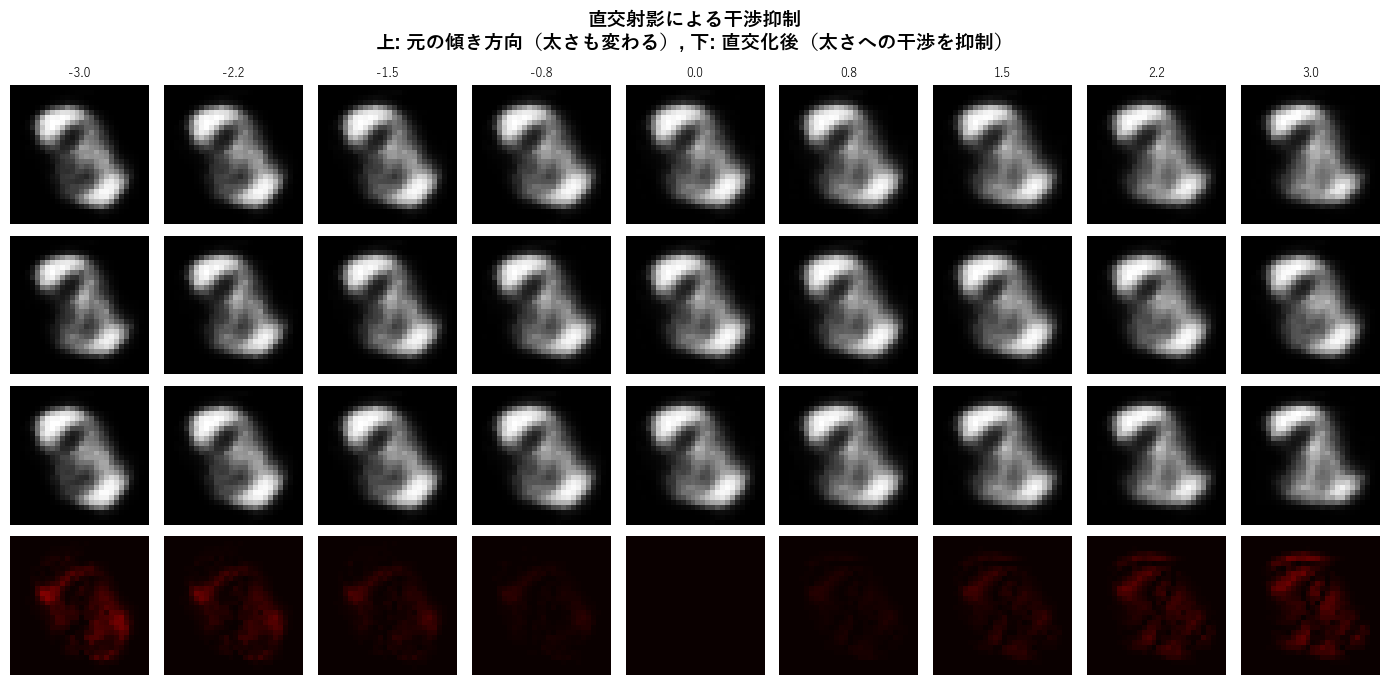

💡 直交化後は、傾きを変えても太さへの影響が小さくなっている
   差分（熱図）の強度が小さいほど、干渉が少ない


In [8]:
# ============================================================
# 直交化前後の属性編集を比較
# 傾き属性: 直交化前 vs 直交化後
# ============================================================

fig, axes = plt.subplots(4, n_steps, figsize=(14, 7))

compare_attr = 'slant'
digit = 3
idx = digit_indices[digit][0]
z_base = all_z[idx]

# 直交化前: 傾き
for col, alpha in enumerate(alphas):
    z_mod = z_base + alpha * directions[compare_attr]
    img = decode_z(z_mod)
    axes[0, col].imshow(img, cmap='gray')
    axes[0, col].axis('off')
    if col == 0: axes[0, col].set_ylabel('傾き\n(元)', fontsize=10, rotation=0, labelpad=40)
    axes[0, col].set_title(f'{alpha:.1f}', fontsize=9)

# 直交化前: 太さ（比較用）
for col, alpha in enumerate(alphas):
    z_mod = z_base + alpha * directions['thickness']
    img = decode_z(z_mod)
    axes[1, col].imshow(img, cmap='gray')
    axes[1, col].axis('off')
    if col == 0: axes[1, col].set_ylabel('太さ\n(元)', fontsize=10, rotation=0, labelpad=40)

# 直交化後: 傾き（太さ成分を除去）
for col, alpha in enumerate(alphas):
    z_mod = z_base + alpha * orthogonal_directions[compare_attr]
    img = decode_z(z_mod)
    axes[2, col].imshow(img, cmap='gray')
    axes[2, col].axis('off')
    if col == 0: axes[2, col].set_ylabel('傾き\n(直交化)', fontsize=10, rotation=0, labelpad=40)

# 差分の比較
for col, alpha in enumerate(alphas):
    z_orig = z_base + alpha * directions[compare_attr]
    z_orth = z_base + alpha * orthogonal_directions[compare_attr]
    img_orig = decode_z(z_orig)
    img_orth = decode_z(z_orth)
    diff = np.abs(img_orig - img_orth)
    axes[3, col].imshow(diff, cmap='hot', vmin=0, vmax=0.5)
    axes[3, col].axis('off')
    if col == 0: axes[3, col].set_ylabel('差分\n(熱図)', fontsize=10, rotation=0, labelpad=40)

fig.suptitle('直交射影による干渉抑制\n上: 元の傾き方向（太さも変わる）, 下: 直交化後（太さへの干渉を抑制）',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_307_03_orthogonal_projection.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 直交化後は、傾きを変えても太さへの影響が小さくなっている")
print("   差分（熱図）の強度が小さいほど、干渉が少ない")

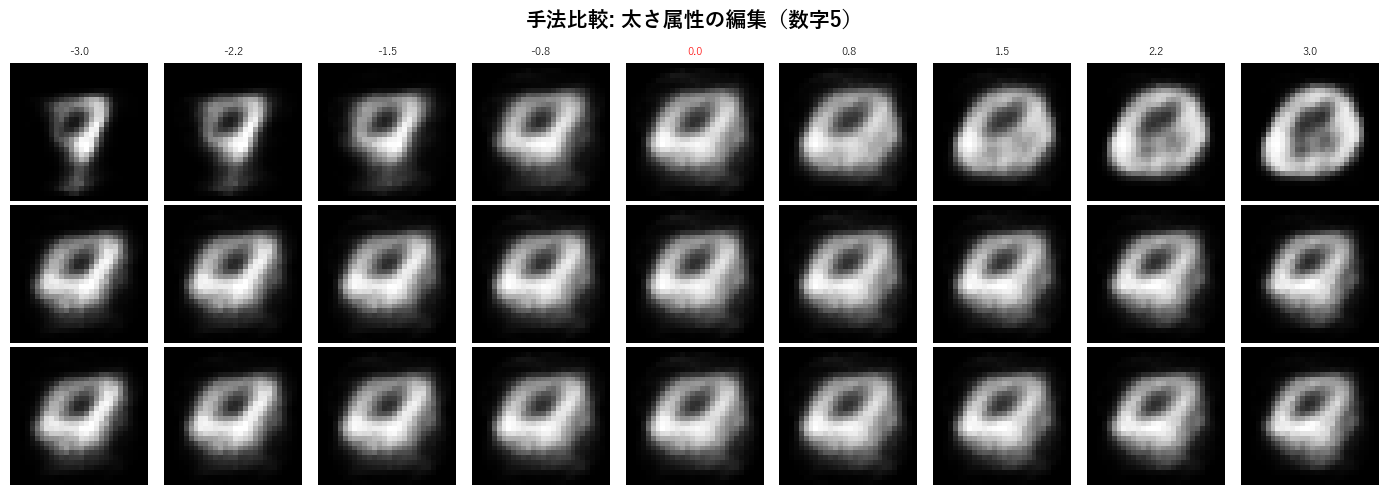

  太さ: 平均差 vs SVM のコサイン類似度 = 0.137
  傾き: 平均差 vs SVM のコサイン類似度 = 0.201
  上下位置: 平均差 vs SVM のコサイン類似度 = 0.062
  幅: 平均差 vs SVM のコサイン類似度 = 0.204


In [9]:
# ============================================================
# 手法比較: グループ平均差 vs InterFaceGAN (SVM)
# ============================================================

# 302章の方法: グループ平均差
mean_directions = {}
for attr_name, attr_labels in attributes.items():
    pos_z = all_z[attr_labels == 1].mean(axis=0)
    neg_z = all_z[attr_labels == 0].mean(axis=0)
    d = pos_z - neg_z
    mean_directions[attr_name] = d / np.linalg.norm(d)

# 2つの手法で同じ属性を編集して比較
fig, axes = plt.subplots(3, n_steps, figsize=(14, 5))

digit = 5
idx = digit_indices[digit][0]
z_base = all_z[idx]
attr = 'thickness'

# 元画像（参照）
axes[0, n_steps//2].set_title('← 元画像 →', fontsize=10, fontweight='bold', color='red')

# グループ平均差
for col, alpha in enumerate(alphas):
    z_mod = z_base + alpha * mean_directions[attr]
    axes[0, col].imshow(decode_z(z_mod), cmap='gray')
    axes[0, col].axis('off')
    if col == 0: axes[0, col].set_ylabel('平均差\n(302章)', fontsize=10, rotation=0, labelpad=45)
    axes[0, col].set_title(f'{alpha:.1f}', fontsize=8)

# InterFaceGAN (SVM)
for col, alpha in enumerate(alphas):
    z_mod = z_base + alpha * directions[attr]
    axes[1, col].imshow(decode_z(z_mod), cmap='gray')
    axes[1, col].axis('off')
    if col == 0: axes[1, col].set_ylabel('SVM\n(本章)', fontsize=10, rotation=0, labelpad=45)

# 直交化SVM
for col, alpha in enumerate(alphas):
    z_mod = z_base + alpha * orthogonal_directions.get(attr, directions[attr])
    axes[2, col].imshow(decode_z(z_mod), cmap='gray')
    axes[2, col].axis('off')
    if col == 0: axes[2, col].set_ylabel('直交化\nSVM', fontsize=10, rotation=0, labelpad=45)

fig.suptitle(f'手法比較: 太さ属性の編集（数字{digit}）',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_307_04_method_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 方向ベクトルの類似度
for attr in attr_names:
    sim = np.dot(mean_directions[attr], directions[attr])
    print(f"  {attr_labels_jp[attr]}: 平均差 vs SVM のコサイン類似度 = {sim:.3f}")

---

## まとめ

### 🎯 このノートブックで学んだこと

**InterFaceGANの原理**
- ✓ SVM境界面の法線ベクトル = 属性方向（数学的に最適な分離面）
- ✓ 302章の「グループ平均差」よりも精度が高い

**属性編集**
- ✓ z' = z + α·n で属性強度を連続的に制御
- ✓ 複数の属性方向を同時に発見・適用可能

**干渉抑制**
- ✓ 属性方向が直交していないと干渉が起きる
- ✓ Gram-Schmidt直交射影で他属性への影響を抑制

### ⚠️ よくある間違い

❌ 「InterFaceGANには大量のラベルが必要」
✅ 数百〜数千サンプルの属性ラベルがあれば十分。全学習データにラベルは不要

❌ 「直交化すれば干渉は完全に解消する」
✅ 線形直交化は線形な干渉しか抑制できない。非線形な干渉は残る

### ✅ 学習チェックリスト

- [ ] InterFaceGANの3ステップ（ラベル→SVM→法線ベクトル）を説明できるか？
- [ ] Gram-Schmidt直交化の数式を書けるか？
- [ ] グループ平均差とSVM法線の違いを説明できるか？

---

**次のステップ**: ノートブック308「GANSpace」で、ラベルなしで属性方向を発見する教師なし手法を学びます！

---

## 🎓 自己評価クイズ

### Q1: InterFaceGANで「属性方向」を見つける際に、なぜSVMを使うのか？

<details>
<summary>💡 答えを見る</summary>

**答え**: SVMは最大マージン分離を行うため、最も安定で代表的な分離面（=属性方向）が得られる

グループ平均差は単なる重心間の方向で、外れ値の影響を受けやすい。
SVMは最大マージンで分離するため、両クラスの境界を最適に見つけ、その法線が属性方向になる。

</details>

---

### Q2: 直交射影 n₂' = n₂ - (n₂·n₁)n₁ の幾何学的な意味は？

<details>
<summary>💡 答えを見る</summary>

**答え**: n₂からn₁方向の成分を取り除き、n₁に対して垂直な成分だけを残す

これにより、n₂'方向に移動してもn₁方向には全く動かなくなる。
つまり属性2を編集しても属性1には影響しない。

</details>

---

### Q3: InterFaceGANは教師あり手法か教師なし手法か？その理由は？

<details>
<summary>💡 答えを見る</summary>

**答え**: 教師あり手法。属性ラベル（笑顔/非笑顔、太い/細い等）が必要

SVMの学習には正解ラベルが不可欠。次章（308章）のGANSpaceは教師なしで属性を発見する手法。

</details>